In [ ]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
# 1. LOAD DATA


file_path = "/content/step3_engineered_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (552, 53)

Columns:
['Student ID', 'Gender', 'Type of Examinee', 'Pre-assessment 2025', 'Anatomy', 'Physiology', 'Parasitology', 'Pharmacology', 'Pathology', 'Zootechnics', 'Microbiology & Public Health', 'Medicine', 'Surgery', 'Post-assessment 2025', 'Pre-assessment 2025_last', 'Anatomy_last', 'Physiology_last', 'Parasitology_last', 'Pharmacology_last', 'Pathology_last', 'Zootechnics_last', 'Microbiology & Public Health_last', 'Medicine_last', 'Surgery_last', 'Post-assessment 2025_last', 'Pre-assessment 2025_best', 'Anatomy_best', 'Physiology_best', 'Parasitology_best', 'Pharmacology_best', 'Pathology_best', 'Zootechnics_best', 'Microbiology & Public Health_best', 'Medicine_best', 'Surgery_best', 'Post-assessment 2025_best', 'avg_best_score', 'max_best_score', 'avg_first_score', 'avg_last_score', 'total_attempts', 'avg_attempts', 'avg_improvement', 'score_std', 'num_exams', 'Licensure Exam Result', 'exam_coverage_ratio', 'best_minus_first', 'last_minus_first', 'best_min

In [ ]:
# 2. TARGET AND FEATURES


target_col = "Licensure Exam Result"
drop_cols = ["Student ID"]  # identifier only

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

# Detect column types
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Number of numeric columns:", len(numeric_cols))


Categorical columns: ['Gender', 'Type of Examinee']
Number of numeric columns: 49


In [ ]:
# 3. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (441, 51)
Test shape: (111, 51)


In [ ]:
# 4. PREPROCESSORS

numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# For models that need scaling
preprocessor_scaled = ColumnTransformer([
    ("num", numeric_scaled, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# For tree-based models
preprocessor_unscaled = ColumnTransformer([
    ("num", numeric_unscaled, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [ ]:
# 5. BUILD MODELS


log_reg_pipe = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree_pipe = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=5,
        min_samples_leaf=10
    ))
])

svm_pipe = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", SVC(
        probability=True,
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_pipe = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        min_samples_leaf=2,
        min_samples_split=5
    ))
])

xgboost_pipe = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    ))
])

models = {
    "Logistic Regression": log_reg_pipe,
    "Decision Tree": decision_tree_pipe,
    "Support Vector Machine": svm_pipe,
    "Random Forest": random_forest_pipe,
    "XGBoost": xgboost_pipe
}

In [ ]:
# 6. CROSS-VALIDATION SETUP


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [ ]:
# 7. BASELINE MODEL COMPARISON

results = []

for model_name, pipeline in models.items():
    print(f"\nRunning: {model_name}")

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "CV AUC Mean": np.mean(cv_scores["test_auc"]),
        "CV Accuracy Mean": np.mean(cv_scores["test_accuracy"]),
        "CV Precision Mean": np.mean(cv_scores["test_precision"]),
        "CV Recall Mean": np.mean(cv_scores["test_recall"]),
        "CV F1 Mean": np.mean(cv_scores["test_f1"]),
        "Test AUC": roc_auc_score(y_test, y_prob),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="Test AUC", ascending=False)
print("\n=== BASELINE MODEL COMPARISON ===")
print(results_df.round(4))

# Save baseline results
results_df.to_csv("/content/step4_baseline_model_comparison.csv", index=False)



Running: Logistic Regression

Running: Decision Tree

Running: Support Vector Machine

Running: Random Forest

Running: XGBoost

=== BASELINE MODEL COMPARISON ===
                    Model  CV AUC Mean  CV Accuracy Mean  CV Precision Mean  \
3           Random Forest       0.7195            0.7461             0.7826   
2  Support Vector Machine       0.7261            0.6895             0.8291   
4                 XGBoost       0.6897            0.7258             0.7787   
0     Logistic Regression       0.6358            0.6123             0.7937   
1           Decision Tree       0.6307            0.6054             0.8069   

   CV Recall Mean  CV F1 Mean  Test AUC  Test Accuracy  Test Precision  \
3          0.9038      0.8386    0.8317         0.7838          0.8065   
2          0.7268      0.7739    0.8177         0.7297          0.8228   
4          0.8728      0.8222    0.8033         0.7748          0.8043   
0          0.6338      0.7044    0.7642         0.6937          0

In [ ]:
# 8. HYPERPARAMETER TUNING

# 8A. Random Forest tuning

rf_base = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_param_dist = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [None, 6, 10, 14],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]


# 8B. XGBoost tuning

xgb_base = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    ))
])

xgb_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

xgb_pred = best_xgb.predict(X_test)
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]


# 8C. SVM tuning

svm_base = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_param_dist = {
    "model__C": [0.1, 1, 10, 50],
    "model__gamma": ["scale", 0.01, 0.1, 1],
    "model__kernel": ["rbf", "linear"]
}

svm_search = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=svm_param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1
)

svm_search.fit(X_train, y_train)
best_svm = svm_search.best_estimator_

svm_pred = best_svm.predict(X_test)
svm_prob = best_svm.predict_proba(X_test)[:, 1]


In [ ]:
# 9. TUNED MODEL RESULTS

tuned_results = pd.DataFrame([
    {
        "Model": "Tuned Random Forest",
        "Best CV AUC": rf_search.best_score_,
        "Test AUC": roc_auc_score(y_test, rf_prob),
        "Test Accuracy": accuracy_score(y_test, rf_pred),
        "Test Precision": precision_score(y_test, rf_pred),
        "Test Recall": recall_score(y_test, rf_pred),
        "Test F1": f1_score(y_test, rf_pred),
        "Best Params": rf_search.best_params_
    },
    {
        "Model": "Tuned XGBoost",
        "Best CV AUC": xgb_search.best_score_,
        "Test AUC": roc_auc_score(y_test, xgb_prob),
        "Test Accuracy": accuracy_score(y_test, xgb_pred),
        "Test Precision": precision_score(y_test, xgb_pred),
        "Test Recall": recall_score(y_test, xgb_pred),
        "Test F1": f1_score(y_test, xgb_pred),
        "Best Params": xgb_search.best_params_
    },
    {
        "Model": "Tuned SVM",
        "Best CV AUC": svm_search.best_score_,
        "Test AUC": roc_auc_score(y_test, svm_prob),
        "Test Accuracy": accuracy_score(y_test, svm_pred),
        "Test Precision": precision_score(y_test, svm_pred),
        "Test Recall": recall_score(y_test, svm_pred),
        "Test F1": f1_score(y_test, svm_pred),
        "Best Params": svm_search.best_params_
    }
]).sort_values(by="Test AUC", ascending=False)

print("\n=== TUNED MODEL COMPARISON ===")
print(tuned_results.round(4))

# Save tuned results
tuned_results.to_csv("/content/step4_tuned_model_comparison.csv", index=False)



=== TUNED MODEL COMPARISON ===
                 Model  Best CV AUC  Test AUC  Test Accuracy  Test Precision  \
0  Tuned Random Forest       0.7275    0.8424         0.7928          0.8222   
2            Tuned SVM       0.7361    0.8177         0.7297          0.8228   
1        Tuned XGBoost       0.6976    0.8091         0.7748          0.7917   

   Test Recall  Test F1                                        Best Params  
0       0.9136   0.8655  {'model__n_estimators': 200, 'model__min_sampl...  
2       0.8025   0.8125  {'model__kernel': 'rbf', 'model__gamma': 'scal...  
1       0.9383   0.8588  {'model__subsample': 0.8, 'model__n_estimators...  


In [ ]:
# 10. CHOOSE FINAL MODEL


final_model_name = tuned_results.iloc[0]["Model"]
print("\nFinal selected model:", final_model_name)

if final_model_name == "Tuned Random Forest":
    best_model = best_rf
elif final_model_name == "Tuned XGBoost":
    best_model = best_xgb
else:
    best_model = best_svm



Final selected model: Tuned Random Forest


In [ ]:
# 11. SAVE MODELS FOR REPRODUCIBILITY

os.makedirs("/content/models", exist_ok=True)

joblib.dump(best_rf, "/content/models/random_forest_final.pkl")
joblib.dump(best_xgb, "/content/models/xgboost_final.pkl")
joblib.dump(best_svm, "/content/models/svm_final.pkl")
joblib.dump(best_model, "/content/models/final_selected_model.pkl")
joblib.dump(X.columns.tolist(), "/content/models/feature_names.pkl")

print("\nModels saved successfully.")


Models saved successfully.


In [ ]:
# 12. LOAD MODEL TEST


loaded_model = joblib.load("/content/models/final_selected_model.pkl")
sample_preds = loaded_model.predict(X_test.iloc[:5])

print("\nSample predictions from loaded model:")
print(sample_preds)


Sample predictions from loaded model:
[1 1 1 0 1]


In [ ]:
# DEFINE TARGET, SUBGROUPS, AND FEATURES

import pandas as pd
import os

file_path = "/content/step3_engineered_dataset.csv"

# Check if the file exists before attempting to read it
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the 'step3_engineered_dataset.csv' file is uploaded to the /content/ directory.")
    print("If you recently restarted the Colab runtime, you might need to re-upload the file or re-run the cell that generates it.")
    raise FileNotFoundError(f"File not found: {file_path}")

df = pd.read_csv(file_path)

target_col = "Licensure Exam Result"
sensitive_cols = ["Gender", "Type of Examinee"]

# Keep original subgroup labels for fairness audit later
audit_df = df[sensitive_cols].copy()

# Separate target
y = df[target_col]

# Drop student identifier and target from X
drop_cols = ["Student ID", target_col]
X_raw = df.drop(columns=drop_cols)

# One-hot encode categorical columns for modeling
X = pd.get_dummies(X_raw, drop_first=True)

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True))

Feature matrix shape: (552, 51)
Target distribution:
Licensure Exam Result
1    403
0    149
Name: count, dtype: int64

Class proportions:
Licensure Exam Result
1    0.730072
0    0.269928
Name: proportion, dtype: float64


In [ ]:
# TRAIN-TEST SPLIT


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, audit_train, audit_test = train_test_split(
    X, y, audit_df,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (441, 51)
Test shape: (111, 51)


In [ ]:
# FINAL MODEL FOR STEP 5

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Final model trained successfully.


SHAP Summary Plot


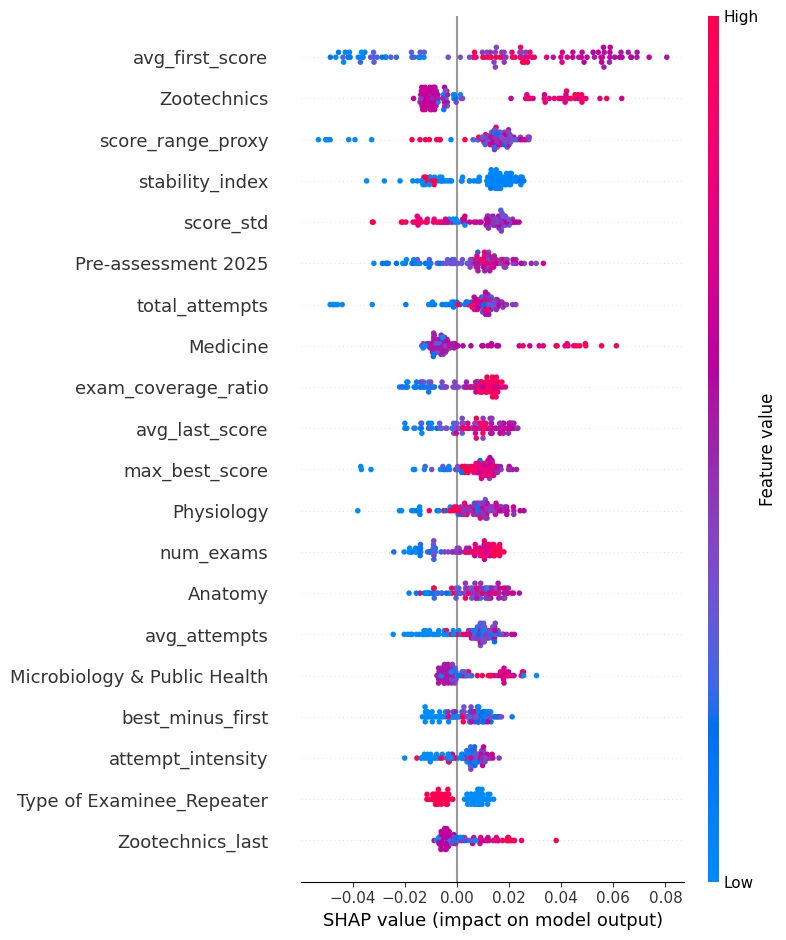

In [ ]:
# 5a. MODEL EXPLAINABILITY WITH SHAP

import shap
import matplotlib.pyplot as plt
import numpy as np  # Import numpy

# Extract fitted components
imputer = final_model.named_steps["imputer"]
rf_model = final_model.named_steps["model"]

# Impute X_test
X_test_imputed = imputer.transform(X_test)
X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

# SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_imputed_df)

# Robust handling of binary classifier SHAP output
if isinstance(shap_values, list):
    shap_positive = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_positive = shap_values[:, :, 1]
else:
    shap_positive = shap_values

print("SHAP Summary Plot")
shap.summary_plot(shap_positive, X_test_imputed_df)

In [ ]:
# TOP PREDICTORS FROM SHAP

mean_abs_shap = np.abs(shap_positive).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_test_imputed_df.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print("Top 15 most influential predictors:")
display(shap_importance.head(15))

Top 15 most influential predictors:


,Feature,MeanAbsSHAP
35,avg_first_score,0.034054
6,Zootechnics,0.018266
48,score_range_proxy,0.017913
47,stability_index,0.014502
40,score_std,0.013394
0,Pre-assessment 2025,0.013246
37,total_attempts,0.012397
8,Medicine,0.012135
42,exam_coverage_ratio,0.011245
36,avg_last_score,0.011194


Explaining prediction for student at test index position 0


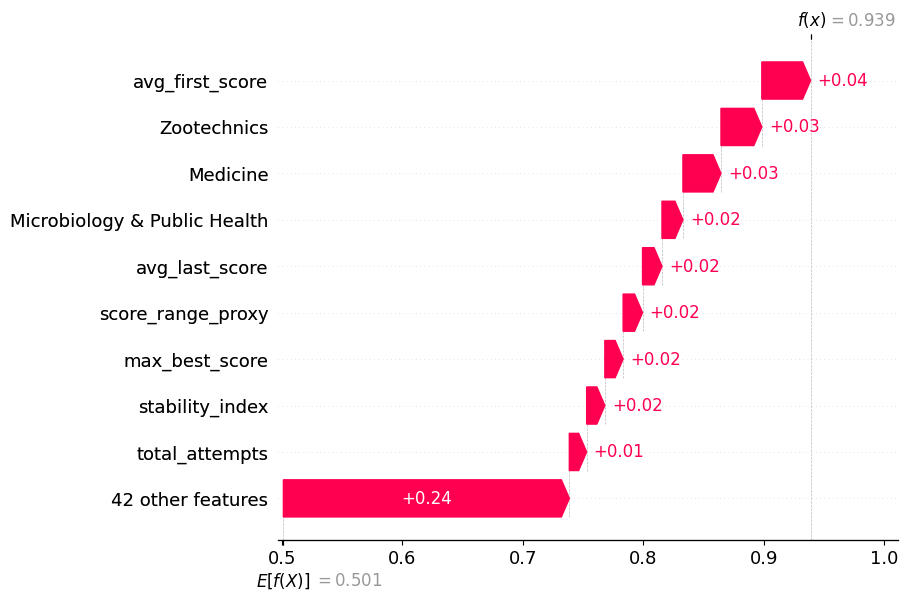

In [ ]:
# EXPLAIN ONE STUDENT PREDICTION

student_idx = 0

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    if len(np.array(expected_value).shape) == 0:
        base_value = float(expected_value)
    elif len(expected_value) > 1:
        base_value = expected_value[1]
    else:
        base_value = expected_value[0]
else:
    base_value = expected_value

print(f"Explaining prediction for student at test index position {student_idx}")

shap.plots._waterfall.waterfall_legacy(
    base_value,
    shap_positive[student_idx],
    feature_names=X_test_imputed_df.columns
)

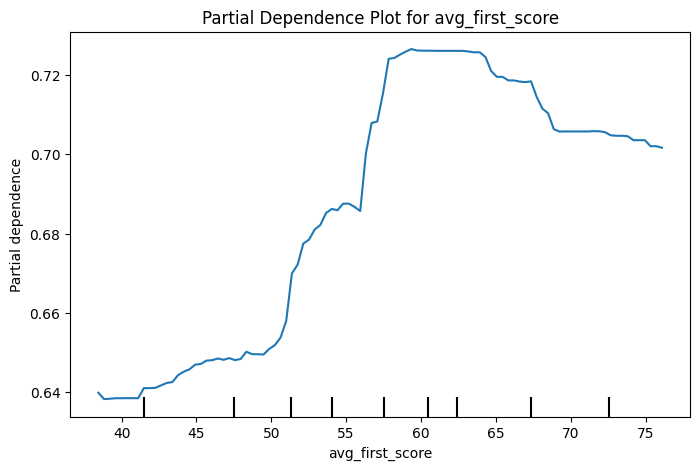

In [ ]:
# PARTIAL DEPENDENCE PLOT

from sklearn.inspection import PartialDependenceDisplay

top_feature = shap_importance.iloc[0]["Feature"]

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    final_model,
    X_test,
    [top_feature],
    ax=ax
)
plt.title(f"Partial Dependence Plot for {top_feature}")
plt.show()

In [ ]:
# PREDICTIONS FOR FAIRNESS ANALYSIS

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

fairness_df = audit_test.copy()
fairness_df["Actual"] = y_test.values
fairness_df["Predicted"] = y_pred
fairness_df["Pred_Prob"] = y_prob

display(fairness_df.head())

,Gender,Type of Examinee,Actual,Predicted,Pred_Prob
501,Male,First Taker,1,1,0.938715
504,Male,Repeater,1,1,0.785715
538,Male,First Taker,1,1,0.788047
44,Female,Repeater,1,0,0.346283
369,Female,First Taker,1,1,0.816764


In [ ]:
# FAIRNESS METRIC FUNCTION

def subgroup_metrics(df, group_col):
    rows = []

    for group_value, subset in df.groupby(group_col, dropna=False):
        y_true = subset["Actual"]
        y_hat = subset["Predicted"]
        y_score = subset["Pred_Prob"]

        tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()

        rows.append({
            "Group": group_value,
            "Count": len(subset),
            "Actual Pass Rate": y_true.mean(),
            "Positive Prediction Rate": y_hat.mean(),
            "Accuracy": accuracy_score(y_true, y_hat),
            "Precision": precision_score(y_true, y_hat, zero_division=0),
            "Recall / TPR": recall_score(y_true, y_hat, zero_division=0),
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "F1": f1_score(y_true, y_hat, zero_division=0),
            "AUC": roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan
        })

    return pd.DataFrame(rows)

In [ ]:
# FAIRNESS AUDIT: GENDER

gender_fairness = subgroup_metrics(fairness_df, "Gender")
print("Fairness metrics by Gender")
display(gender_fairness)

Fairness metrics by Gender


,Group,Count,Actual Pass Rate,Positive Prediction Rate,Accuracy,Precision,Recall / TPR,FPR,FNR,F1,AUC
0,Female,76,0.684211,0.802632,0.723684,0.754098,0.884615,0.625000,0.115385,0.814159,0.776442
1,Male,35,0.828571,0.828571,0.885714,0.931034,0.931034,0.333333,0.068966,0.931034,0.959770


In [ ]:
# FAIRNESS AUDIT: TYPE OF EXAMINEE

examinee_fairness = subgroup_metrics(fairness_df, "Type of Examinee")
print("Fairness metrics by Type of Examinee")
display(examinee_fairness)

Fairness metrics by Type of Examinee


,Group,Count,Actual Pass Rate,Positive Prediction Rate,Accuracy,Precision,Recall / TPR,FPR,FNR,F1,AUC
0,First Taker,59,0.830508,0.881356,0.847458,0.884615,0.938776,0.60,0.061224,0.910891,0.897959
1,Repeater,52,0.615385,0.730769,0.692308,0.710526,0.843750,0.55,0.156250,0.771429,0.748437


In [ ]:
# FAIRNESS AUDIT: INTERSECTIONAL GROUPS

fairness_df["Gender x Examinee"] = (
    fairness_df["Gender"].astype(str) + " | " + fairness_df["Type of Examinee"].astype(str)
)

intersection_fairness = subgroup_metrics(fairness_df, "Gender x Examinee")
print("Fairness metrics by Gender x Type of Examinee")
display(intersection_fairness)

Fairness metrics by Gender x Type of Examinee


,Group,Count,Actual Pass Rate,Positive Prediction Rate,Accuracy,Precision,Recall / TPR,FPR,FNR,F1,AUC
0,Female | First Taker,32,0.781250,0.906250,0.812500,0.827586,0.960000,0.714286,0.040000,0.888889,0.874286
1,Female | Repeater,44,0.613636,0.727273,0.659091,0.687500,0.814815,0.588235,0.185185,0.745763,0.708061
2,Male | First Taker,27,0.888889,0.851852,0.888889,0.956522,0.916667,0.333333,0.083333,0.936170,0.944444
3,Male | Repeater,8,0.625000,0.750000,0.875000,0.833333,1.000000,0.333333,0.000000,0.909091,1.000000


In [ ]:
# DISPARATE IMPACT

def disparate_impact(df, group_col):
    rates = df.groupby(group_col)["Predicted"].mean().sort_values()
    min_rate = rates.min()
    max_rate = rates.max()
    ratio = min_rate / max_rate if max_rate > 0 else np.nan

    di_table = pd.DataFrame({
        "Group": rates.index,
        "Positive Prediction Rate": rates.values
    })

    return di_table, ratio

gender_di_table, gender_di_ratio = disparate_impact(fairness_df, "Gender")
examinee_di_table, examinee_di_ratio = disparate_impact(fairness_df, "Type of Examinee")

print("Gender Disparate Impact Table")
display(gender_di_table)
print(f"Gender Disparate Impact Ratio: {gender_di_ratio:.3f}")

print("\nType of Examinee Disparate Impact Table")
display(examinee_di_table)
print(f"Type of Examinee Disparate Impact Ratio: {examinee_di_ratio:.3f}")

Gender Disparate Impact Table


,Group,Positive Prediction Rate
0,Female,0.802632
1,Male,0.828571


Gender Disparate Impact Ratio: 0.969

Type of Examinee Disparate Impact Table


,Group,Positive Prediction Rate
0,Repeater,0.730769
1,First Taker,0.881356


Type of Examinee Disparate Impact Ratio: 0.829


In [ ]:
# EQUALIZED ODDS GAPS

def equalized_odds_gap(fairness_table):
    tpr_gap = fairness_table["Recall / TPR"].max() - fairness_table["Recall / TPR"].min()
    fpr_gap = fairness_table["FPR"].max() - fairness_table["FPR"].min()
    return pd.DataFrame({
        "TPR Gap": [tpr_gap],
        "FPR Gap": [fpr_gap]
    })

print("Equalized Odds Gap - Gender")
display(equalized_odds_gap(gender_fairness))

print("Equalized Odds Gap - Type of Examinee")
display(equalized_odds_gap(examinee_fairness))

print("Equalized Odds Gap - Gender x Type of Examinee")
display(equalized_odds_gap(intersection_fairness))

Equalized Odds Gap - Gender


,TPR Gap,FPR Gap
0,0.046419,0.291667


Equalized Odds Gap - Type of Examinee


,TPR Gap,FPR Gap
0,0.095026,0.05


Equalized Odds Gap - Gender x Type of Examinee


,TPR Gap,FPR Gap
0,0.185185,0.380952


In [ ]:
# PROXY-SENSITIVE FEATURE SCAN

potential_proxy_keywords = ["gender", "sex", "school", "university", "region", "location", "income", "age"]

proxy_features = [
    col for col in X.columns
    if any(keyword in col.lower() for keyword in potential_proxy_keywords)
]

print("Potential proxy-sensitive features found in model inputs:")
if proxy_features:
    for feat in proxy_features:
        print("-", feat)
else:
    print("No obvious proxy-sensitive features found based on column names.")

Potential proxy-sensitive features found in model inputs:
- exam_coverage_ratio
- Gender_Male


In [ ]:
# CLASS IMBALANCE CHECK

class_counts = y.value_counts()
class_props = y.value_counts(normalize=True)

print("Class counts:")
print(class_counts)

print("\nClass proportions:")
print(class_props)

Class counts:
Licensure Exam Result
1    403
0    149
Name: count, dtype: int64

Class proportions:
Licensure Exam Result
1    0.730072
0    0.269928
Name: proportion, dtype: float64


In [ ]:
# POTENTIAL LEAKAGE / RISK REVIEW

possible_leakage_keywords = ["post", "best", "last", "licensure", "result"]

flagged_features = [
    col for col in X.columns
    if any(keyword in col.lower() for keyword in possible_leakage_keywords)
]

print("Features that may require leakage review:")
for col in flagged_features:
    print("-", col)

Features that may require leakage review:
- Post-assessment 2025
- Pre-assessment 2025_last
- Anatomy_last
- Physiology_last
- Parasitology_last
- Pharmacology_last
- Pathology_last
- Zootechnics_last
- Microbiology & Public Health_last
- Medicine_last
- Surgery_last
- Post-assessment 2025_last
- Pre-assessment 2025_best
- Anatomy_best
- Physiology_best
- Parasitology_best
- Pharmacology_best
- Pathology_best
- Zootechnics_best
- Microbiology & Public Health_best
- Medicine_best
- Surgery_best
- Post-assessment 2025_best
- avg_best_score
- max_best_score
- avg_last_score
- best_minus_first
- last_minus_first
- best_minus_last


In [ ]:
# MITIGATION STRATEGIES

mitigation_strategies = [
    "Use stratified train-test split and cross-validation.",
    "Apply class_weight='balanced' or resampling if minority-class recall is weak.",
    "Compare fairness metrics across Gender and Type of Examinee before deployment.",
    "Avoid using features unavailable at the intended prediction time.",
    "Build separate early-warning and late-stage models if needed.",
    "Monitor false negatives carefully because at-risk students may be missed.",
    "Use model outputs only for advising and intervention, not for exclusionary decisions.",
    "Re-audit fairness on future cohorts before operational deployment."
]

print("Recommended mitigation strategies:")
for i, item in enumerate(mitigation_strategies, 1):
    print(f"{i}. {item}")

Recommended mitigation strategies:
1. Use stratified train-test split and cross-validation.
2. Apply class_weight='balanced' or resampling if minority-class recall is weak.
3. Compare fairness metrics across Gender and Type of Examinee before deployment.
4. Avoid using features unavailable at the intended prediction time.
5. Build separate early-warning and late-stage models if needed.
6. Monitor false negatives carefully because at-risk students may be missed.
7. Use model outputs only for advising and intervention, not for exclusionary decisions.
8. Re-audit fairness on future cohorts before operational deployment.


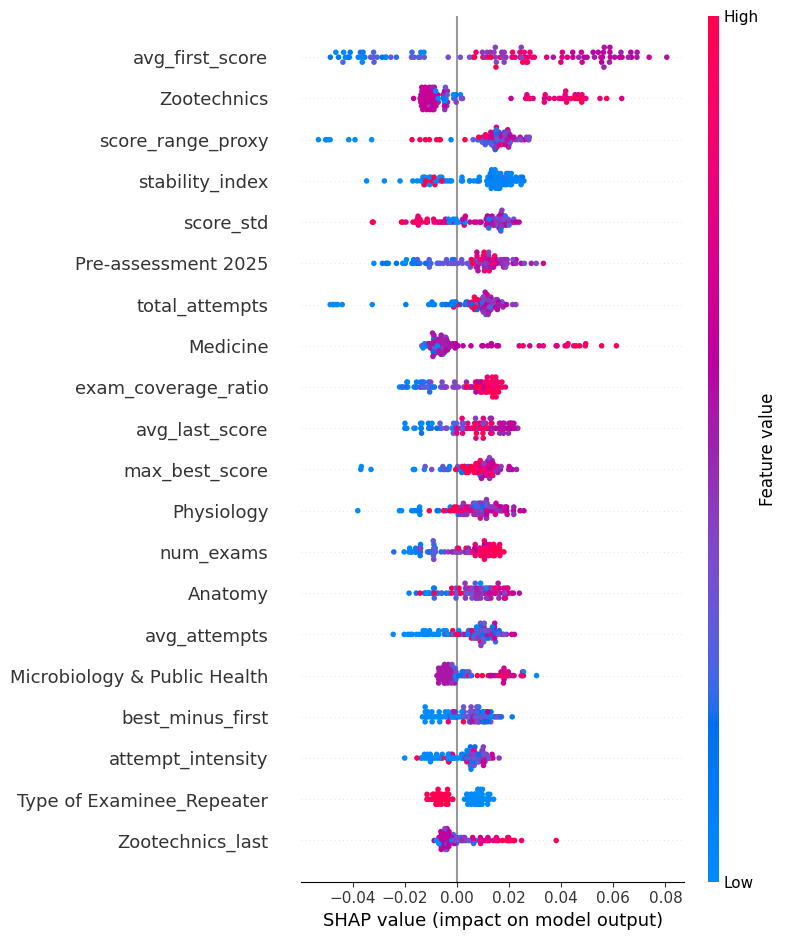

In [ ]:
shap.summary_plot(shap_positive, X_test_imputed_df)

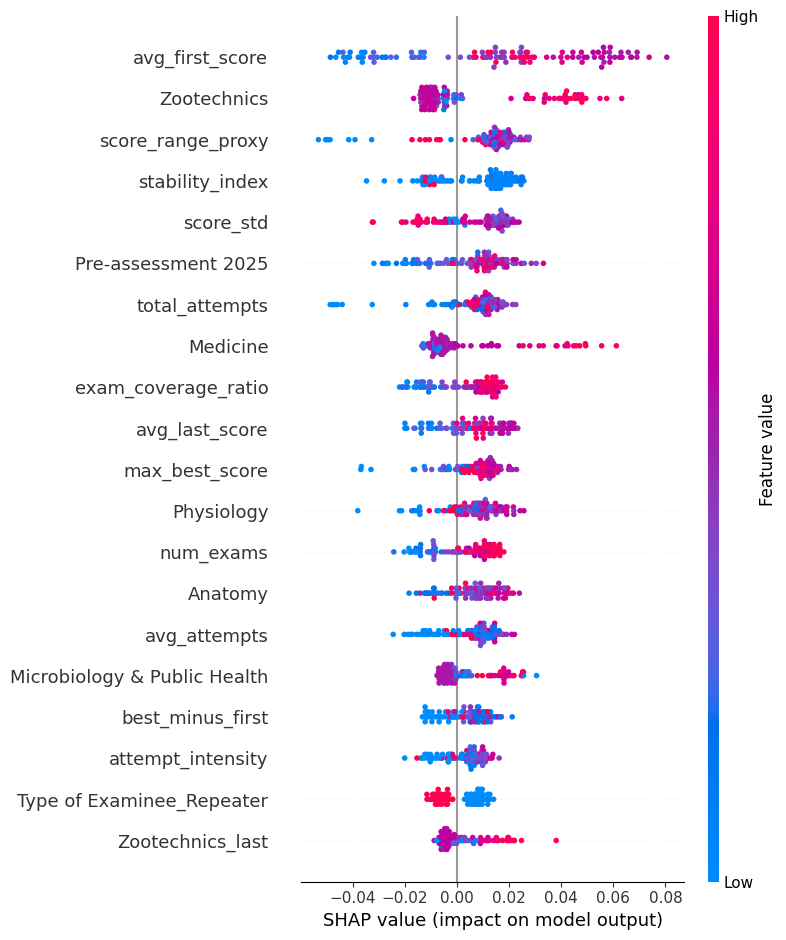

In [ ]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_positive, X_test_imputed_df, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

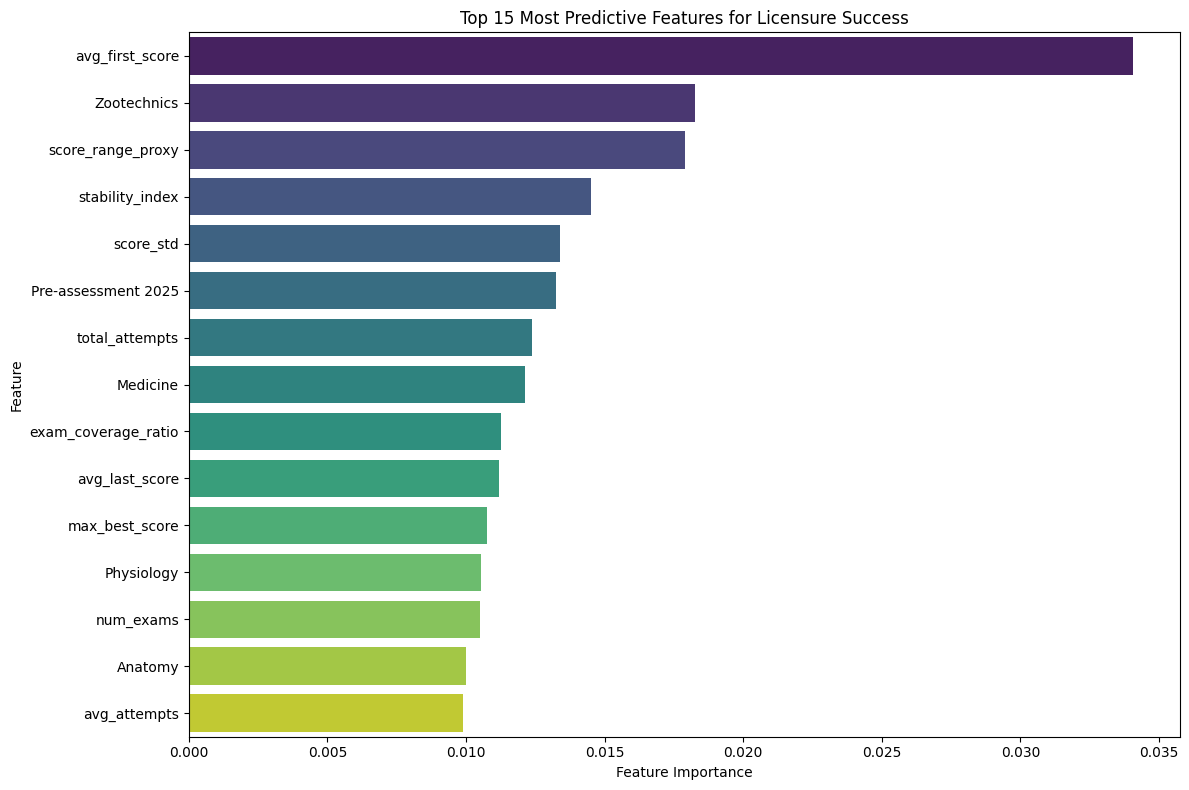

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.barplot(x='MeanAbsSHAP', y='Feature', data=shap_importance.head(15), palette='viridis')
plt.title('Top 15 Most Predictive Features for Licensure Success')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

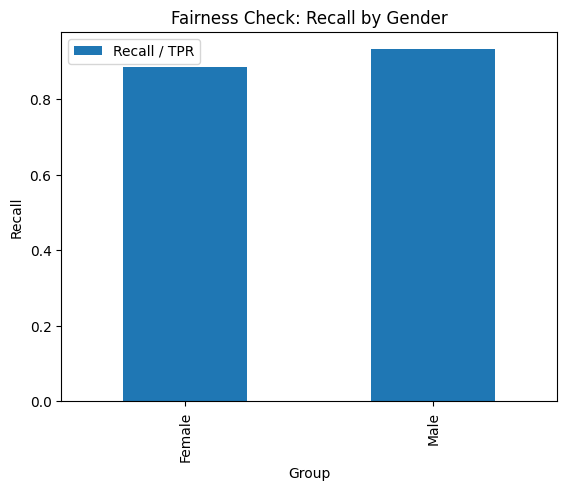

In [ ]:
gender_fairness.plot(x="Group", y="Recall / TPR", kind="bar")
plt.title("Fairness Check: Recall by Gender")
plt.ylabel("Recall")
plt.savefig("fairness_gender.png", bbox_inches='tight')
plt.show()

In [ ]:
print(shap_importance.head())
print(X_test_imputed_df.shape)
print(type(shap_positive))

              Feature  MeanAbsSHAP
35    avg_first_score     0.034054
6         Zootechnics     0.018266
48  score_range_proxy     0.017913
47    stability_index     0.014502
40          score_std     0.013394
(111, 51)
<class 'numpy.ndarray'>
